<a href="https://colab.research.google.com/github/arsingla786/MLFromScratch/blob/main/Weight_Initialization(model_imporvement_ANN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_moons

In [9]:
X,y = make_moons(n_samples=500, noise=0.2, random_state=0)

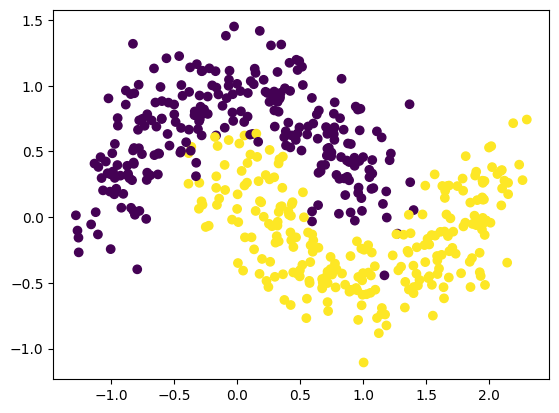

In [10]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y)

In [7]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()
model.add(Dense(3,activation='relu',input_dim=2))
model.add(Dense(1,activation = 'sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
initial_weights = model.get_weights()

In [ ]:
initial_weights

[array([[ 0.4440546 , -0.374654  , -0.11882812],
        [-0.799598  , -0.64191043, -1.0860828 ]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[-0.45937687],
        [ 0.3410194 ],
        [-0.7043896 ]], dtype=float32),
 array([0.], dtype=float32)]

##**Case 1 -> Zero Initialization**

In [ ]:
#set all initial weights to zero\
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [ ]:
model.set_weights(initial_weights)

In [ ]:
model.get_weights()

[array([[0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.4700 - val_loss: 0.6932
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.4700 - val_loss: 0.6932
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.4700 - val_loss: 0.6933
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.4700 - val_loss: 0.6933
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.4700 - val_loss: 0.6933
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.4700 - val_loss: 0.6934
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.4700 - val_loss: 0.6934
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.4

In [ ]:
model.get_weights()

[array([[0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.]], dtype=float32),
 array([-0.03110218], dtype=float32)]

In [ ]:
#we can clearly see that there is no imporovemnt in model due to zero weights initialiation and relu activation

In [ ]:
#using sigmoid

model1 = Sequential()

model1.add(Dense(3,activation='sigmoid',input_dim=2))
model1.add(Dense(1,activation = 'sigmoid'))

In [ ]:
model1.set_weights(initial_weights)

In [ ]:
model1.get_weights()

[array([[0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model1.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4675 - loss: 0.6932 - val_accuracy: 0.4700 - val_loss: 0.6932
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.4700 - val_loss: 0.6933
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5075 - loss: 0.6932 - val_accuracy: 0.4700 - val_loss: 0.6935
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.4700 - val_loss: 0.6935
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5075 - loss: 0.6930 - val_accuracy: 0.4700 - val_loss: 0.6934
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5075 - loss: 0.6930 - val_accuracy: 0.4700 - val_loss: 0.6935
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5075 - loss: 0.6928 - val_accuracy: 0.4700 - val_loss: 0.6935
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5075 - loss: 0.6927 - val_accuracy: 0.47

In [ ]:
 #here all weights will be same as sigmoid(0) 0.5 and derivative =0.25 , so every weight act as a single node combined

##Case 2 -> Non zero constant value  w=0.5, b= 0.5

In [ ]:
model = Sequential()
model.add(Dense(3,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.get_weights()

[array([[0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[0.],
        [0.],
        [0.]], dtype=float32),
 array([-0.03110218], dtype=float32)]

In [ ]:
initial_weights = model.get_weights()

In [ ]:
initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [ ]:
model.set_weights(initial_weights)

In [ ]:
model.get_weights()

[array([[0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]], dtype=float32),
 array([0.5, 0.5, 0.5], dtype=float32),
 array([[0.5],
        [0.5],
        [0.5]], dtype=float32),
 array([0.5], dtype=float32)]

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
model.fit(X,y,epochs=50,validation_split=0.2)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4925 - loss: 1.0332 - val_accuracy: 0.5300 - val_loss: 0.9672
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4925 - loss: 1.0074 - val_accuracy: 0.5300 - val_loss: 0.9424
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4925 - loss: 0.9821 - val_accuracy: 0.5300 - val_loss: 0.9193
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4925 - loss: 0.9583 - val_accuracy: 0.5300 - val_loss: 0.8979
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4925 - loss: 0.9362 - val_accuracy: 0.5300 - val_loss: 0.8774
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4925 - loss: 0.9161 - val_accuracy: 0.5300 - val_loss: 0.8582
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4925 - loss: 0.8967 - val_accuracy: 0.5300 - val_loss: 0.8405
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4925 - loss: 0.8794 - val_accuracy: 0.5300 - val_loss

In [ ]:
model.get_weights()

[array([[0.7032649 , 0.7032649 , 0.7032649 ],
        [0.06852062, 0.06852062, 0.06852062]], dtype=float32),
 array([0.22029334, 0.22029334, 0.22029334], dtype=float32),
 array([[0.23101617],
        [0.23101617],
        [0.23101617]], dtype=float32),
 array([0.03238184], dtype=float32)]

In [ ]:
#Observe every weight from a node is same

##relu -> he- initialization (variance based)  he_normal, he_uniform
##tanh -> glorol_initialization glorot_noprmal, glorot_uniform

##multiply np.random.randn(input shape) * root(1/n)  where n = previous layer  nodes

In [13]:
model = Sequential()

from keras.initializers import he_uniform,he_normal

model.add(Dense(10,activation='relu',kernel_initializer='he_uniform',input_dim=2))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [15]:
model.fit(X,y,epochs=100,validation_split=0.2,verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 808us/step


<Axes: >

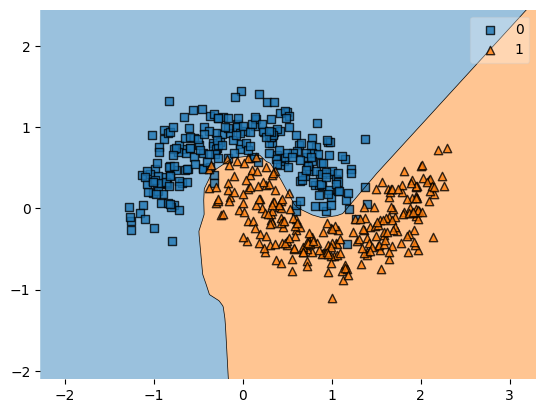

In [16]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X=X,y=y,clf=model)
#